In [2]:
import numpy as np
from typing import Optional
from typing import Callable
from typing import Tuple
import heapq

import torch
import torch.nn as nn
import torch.optim as optim

import math
from collections.abc import Iterable

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/leonardoangellotti/Desktop/universita/unsupervised/esame/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/leonardoangellotti/Desktop/universita/unsupervised/esame/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/leonardoangellotti/Desktop/universita/u

## Synthetic Swiss Roll Dataset

The **swiss roll** is a two–dimensional manifold embedded in three–dimensional space.
It is parameterised by a scalar variable $t$ which controls the winding of the spiral.
For a given number of points $N$, we sample $t$ uniformly in an interval and compute the coordinates as

$$x(t) = t\,\sin(t), \quad y(t) \sim \mathcal{U}(-5,5), \quad z(t) = t\,\cos(t).$$

Here $y$ is drawn uniformly to introduce thickness to the roll.  The angle $t$ is stored separately for colouring purposes.  

In [3]:
def create_swiss_roll(num_points: int) -> np.ndarray:
    """
    Generate a synthetic swiss roll dataset.
    """

    # Allocate output array
    dataset = np.zeros((num_points, 4), dtype=np.float32)

    # Parameter that winds the roll; sampling between 2 and 10 yields a
    # similar distribution to the original implementation
    angle = np.linspace(2.0, 10.0, num_points).astype(np.float32)

    # Compute coordinates: x and z are spiral coordinates, y is random
    dataset[:, 0] = angle * np.sin(angle)
    dataset[:, 2] = angle * np.cos(angle)
    dataset[:, 1] = np.random.uniform(-5.0, 5.0, num_points).astype(np.float32)

    # Store the angular parameter for colouring in visualisations
    dataset[:, 3] = angle
    return dataset

plot function

In [4]:
def plot_swiss_roll(points: np.ndarray, elev: int = 10, azim: int = 45) -> None:
    """
    points : Columns 0-2 are x, y, z coordinates; column 3 is angle for coloring.
    elev : Elevation angle for 3D view.
    azim : Azimuth angle for 3D view.
    """

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    x, y, z, angle = points[:, 0], points[:, 1], points[:, 2], points[:, 3]

    scatter = ax.scatter(x, y, z, c=angle, cmap='plasma', s=5, alpha=0.8)
    fig.colorbar(scatter, ax=ax, label='Angle')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=elev, azim=azim)
    ax.set_title('Swiss Roll')

    plt.tight_layout()
    plt.show()

check plot 

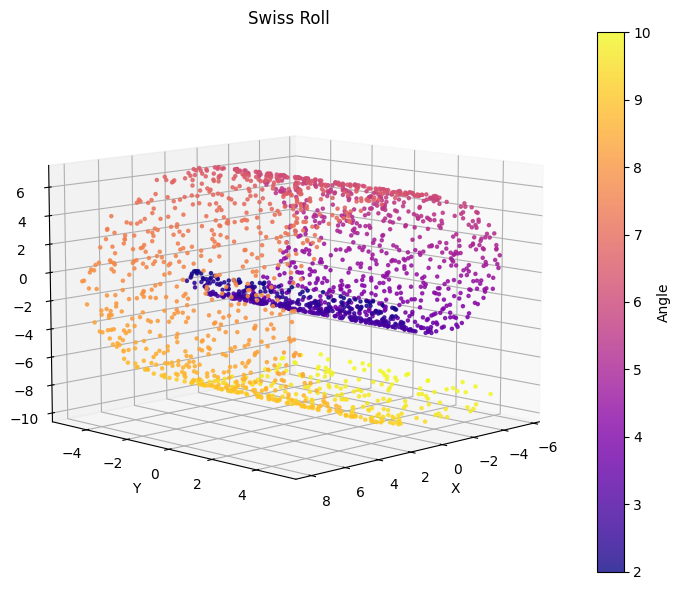

In [5]:
points = create_swiss_roll(2000)
plot_swiss_roll(points)

## EmbeddingRefiner: Manifold Sculpting Algorithm

The **Manifold Sculpting** algorithm iteratively constructs a low-dimensional embedding while preserving local neighbourhood structure. The main steps are:

1. **Neighbourhood graph:**
   For each point $i$, find its $k$ nearest neighbours. Denote their indices by $\mathcal{N}_i$ and distances by $\delta_{i,j}$.

2. **Angular targets:**
   For each neighbour $j\in\mathcal{N}_i$, choose a third point $k\in\mathcal{N}_j$ such that the angle
   $\theta_{i,j,k}$ between vectors $\mathbf{a}=\mathbf{x}_i-\mathbf{x}_j$ and $\mathbf{b}=\mathbf{x}_k-\mathbf{x}_j$ is closest to $\pi$.
   Store this angle as $\theta^0_{i,j}$.

3. **Initialisation:**
   Align the data to its principal components via PCA. Define two sets of coordinate axes:
   preserved dimensions $\mathcal{D}_\mathrm{pres}$ and shrinking dimensions $\mathcal{D}_\mathrm{shrink}$.

4. **Scaling:**
   Multiply coordinates in $\mathcal{D}_\mathrm{shrink}$ by a factor $\sigma < 1$ (“damping”) and, if necessary, divide coordinates in $\mathcal{D}_\mathrm{pres}$ by $\sigma$ to maintain the average neighbour distance

   
   $
   \bar{\delta} =
   \frac{1}{|E|}\sum_{(i,j)\in E} |\mathbf{y}_i - \mathbf{y}_j|,
   $

   where $E$ is the set of all directed edges in the neighbourhood graph.

5. **Point adjustment:**
   Perform a breadth-first traversal of the neighbourhood graph starting from a random point.
   For each visited point $p$, adjust its preserved coordinates $y_{p,d}$ by small increments $\pm \eta$ to minimise the error

   
   $
   E_p = \sum_{j\in\mathcal{N}_p} w_{p,j} \left[
   \frac{1}{2}\left(
   \frac{|\mathbf{y}_p-\mathbf{y}_j| - \delta_{p,j}}{\bar{\delta}}
   \right)^2
   +
   \left(
   \frac{\theta_{p,j} - \theta^0_{p,j}}{\pi}
   \right)^2
   \right],
   $

   where $w_{p,j}$ is a weight that emphasises neighbours already adjusted in this epoch.

6. **Learning rate adaptation:**
   Increase the learning rate if many coordinate updates succeed; otherwise decrease it.
   Repeat until convergence or a maximum number of epochs is reached.

This procedure converges to an embedding where local distances and angles approximate those of the original data, effectively ''sculpting'' away undesired dimensions.

In [6]:
class EmbeddingRefiner:
    # Initialize the refiner with configuration parameters
    def __init__(
        self,
        neighbors: int = 10,  # Number of nearest neighbors to consider for each point
        embedding_dim: int = 2,  # Number of dimensions to keep/preserve in the embedding
        max_epochs: int = 50,  # Maximum number of optimisation iterations (epochs)
        damping: float = 0.9,  # Factor by which we shrink less-important dimensions each epoch
        align_to_pcs: bool = True,  # Whether to initialise using PCA components
        early_stopping: int = 10,  # Stop if no improvement after this many epochs
    ):
        self.neighbors = int(neighbors)  # Store the number of neighbors as an integer
        self.embedding_dim = int(embedding_dim)  # Store the embedding dimensionality
        self.max_epochs = int(max_epochs)  # Store the maximum number of epochs
        self.damping = float(damping)  # Store the damping factor
        self.align_to_pcs = bool(align_to_pcs)  # Store whether to align to principal components
        self.early_stopping = int(early_stopping)  # Store early stopping patience

        self.dataset: Optional[np.ndarray] = None  # Will hold the original high-dimensional data
        self.positions: Optional[np.ndarray] = None  # Will hold current embedding positions
        self.best_positions: Optional[np.ndarray] = None  # Will hold best embedding found so far

        self.neighbor_indices: Optional[np.ndarray] = None  # Indices of nearest neighbors for each point
        self.target_distances: Optional[np.ndarray] = None  # Original distances to neighbors
        self.avg_target_distance: float = 0.0  # Average of all neighbor distances

        self.neighbor_collinear: Optional[np.ndarray] = None  # Indices of collinear neighbor points
        self.target_angles: Optional[np.ndarray] = None  # Target angles between neighbor triplets

        self.dims_preserved: Optional[np.ndarray] = None  # Dimensions kept as main embedding dims
        self.dims_shrunk: Optional[np.ndarray] = None  # Dimensions that will be damped away

        self.step_scale: float = 0.0  # Step size scale for local optimisation
        self.current_scale: float = 1.0  # Global scale factor for shrinkage

        self.last_loss: float = 0.0  # Loss value from the last epoch
        self.best_loss: float = float("inf")  # Best (lowest) loss observed so far
        self.epochs_run: int = 0  # Number of epochs actually performed

    # Fit the refiner to a dataset and compute an embedding
    def fit(self, data: np.ndarray) -> None:
        self.dataset = np.asarray(data, dtype=np.float32)  # Store dataset as float32 NumPy array

        n_samples, n_features = self.dataset.shape  # Get number of samples and features

        # Prepare the neighbor graph and target geometry quantities
        (
            self.neighbor_indices,
            self.target_distances,
            self.avg_target_distance,
            self.neighbor_collinear,
            self.target_angles,
        ) = self._prepare_graph()

        # Set initial step scale based on average neighbor distance
        self.step_scale = float(self.avg_target_distance)

        # If requested, initialise positions using PCA
        if self.align_to_pcs:
            self.positions = self._compute_pca()  # Project onto PCA components
            # First embedding_dim components are preserved dimensions
            self.dims_preserved = np.arange(self.embedding_dim, dtype=np.int32)
            # Remaining dimensions are considered for shrinking
            self.dims_shrunk = np.arange(self.embedding_dim, n_features, dtype=np.int32)
        else:
            # Alternative initialisation: use feature variance to choose preserved dimensions
            cov = np.cov(self.dataset.T)  # Covariance matrix of features
            variances = np.diag(cov)  # Variance of each feature
            ordered = np.argsort(-variances).astype(np.int32)  # Indices of features by descending variance
            self.dims_preserved = ordered[: self.embedding_dim]  # Most variable features are preserved
            self.dims_shrunk = ordered[self.embedding_dim :]  # Less variable ones are shrunk
            self.positions = self.dataset.copy()  # Start from original data positions

        # Ensure positions are float32
        self.positions = np.asarray(self.positions, dtype=np.float32)
        self.current_scale = 1.0  # current scale
        iteration = 0  # Epoch counter

        # Main optimisation loop with early stopping
        epochs_without_improvement = 0  # Counter for epochs with no loss improvement
        mean_error = float("inf")  # Track mean error from last epoch
        self.best_positions = None  # best positions

        # Loop until we hit max_epochs or early stopping condition
        while iteration < self.max_epochs and epochs_without_improvement < self.early_stopping:
            mean_error = self._epoch_step()  # Perform one optimisation epoch and get mean error
            iteration += 1  # Increase epoch count

            # If the error improved, update best records
            if mean_error < self.best_loss:
                self.best_loss = mean_error  # Store new best loss
                self.best_positions = self.positions.copy()  # Store copy of current positions
                epochs_without_improvement = 0  # Reset non-improvement counter
            else:
                # No improvement this epoch
                epochs_without_improvement += 1

        # Final bookkeeping after optimisation loop
        self.epochs_run = iteration  # Store number of epochs actually run
        self.last_loss = mean_error  # Store last mean error

        # Ensure we have a valid best embedding even if no improvement was recorded
        if self.best_positions is None:
            self.best_positions = self.positions.copy()  # Fallback to final positions

    # Construct neighbor graph and geometry relations from the dataset
    def _prepare_graph(self) -> Tuple[np.ndarray, np.ndarray, float, np.ndarray, np.ndarray]:
        assert self.dataset is not None  # Make sure dataset is available
        data = self.dataset  # Local alias for convenience

        n_samples = data.shape[0]  # Number of points in dataset

        # Compute squared norms of all points
        squared_norms = np.sum(data * data, axis=1)

        # Compute Gram matrix (dot products between points)
        gram = data @ data.T

        # Construct full pairwise distance matrix using the Gram trick
        dist_matrix = np.sqrt(
            np.maximum(
                0.0,
                squared_norms[:, None] - 2 * gram + squared_norms[None, :],
            )
        ).astype(np.float32)

        # Arrays to store neighbor indices and distances
        neigh_idx = np.zeros((n_samples, self.neighbors), dtype=np.int32)
        neigh_dist = np.zeros((n_samples, self.neighbors), dtype=np.float32)

        # For each point, find its nearest neighbors
        for idx in range(n_samples):
            order = np.argsort(dist_matrix[idx])  # Sort neighbors by distance
            neighbours_for_idx = order[1 : self.neighbors + 1]  # Skip self at index 0
            neigh_idx[idx] = neighbours_for_idx  # Store neighbor indices
            neigh_dist[idx] = dist_matrix[idx, neighbours_for_idx]  # Store neighbor distances

        # Arrays to store collinear neighbor indices and angles
        collinear_idx = np.zeros((n_samples, self.neighbors), dtype=np.int32)
        angles = np.zeros((n_samples, self.neighbors), dtype=np.float32)

        # For each point i, and each neighbor j, find a point k collinear with i and j
        for i in range(n_samples):
            for j_pos, j in enumerate(neigh_idx[i]):
                a_vec = data[i] - data[j]  # Vector from j to i
                norm_a = np.linalg.norm(a_vec)  # Length of that vector

                if norm_a == 0:
                    # If vectors are identical, treat i and j as collinear with zero angle
                    collinear_idx[i, j_pos] = j
                    angles[i, j_pos] = 0.0
                    continue

                candidate_angles = np.zeros(self.neighbors, dtype=np.float32)  # Angles to candidate k points

                # For each neighbor k of j, compute angle θ_ikj
                for k_pos, k in enumerate(neigh_idx[j]):
                    b_vec = data[k] - data[j]  # Vector from j to k
                    norm_b = np.linalg.norm(b_vec)  # Length of that vector

                    if norm_b == 0:
                        # Degenerate case: k coincides with j, set angle to pi
                        candidate_angles[k_pos] = math.pi
                    else:
                        # Compute cosine of angle between a_vec and b_vec
                        cos_theta = np.dot(a_vec, b_vec) / (norm_a * norm_b)
                        # Clamp to valid range for numerical stability
                        cos_theta = max(min(cos_theta, 1.0), -1.0)
                        candidate_angles[k_pos] = math.acos(cos_theta)  # Convert to actual angle

                # Choose k such that angle is closest to pi (collinearity condition)
                idx_min = np.argmin(np.abs(candidate_angles - math.pi))
                collinear_idx[i, j_pos] = neigh_idx[j, idx_min]  # Store collinear neighbor index
                angles[i, j_pos] = candidate_angles[idx_min]  # Store corresponding angle

        # Compute average neighbor distance (used as scale reference)
        avg_dist = float(np.mean(neigh_dist)) if neigh_dist.size > 0 else 0.0

        # Return neighbor indices, neighbor distances, average distance, collinear indices, and angles
        return neigh_idx, neigh_dist, avg_dist, collinear_idx, angles

    # Compute PCA projection of the dataset
    def _compute_pca(self) -> np.ndarray:
        assert self.dataset is not None  # Ensure data is available
        data = self.dataset  # Local alias

        covariance = np.cov(data.T)  # Compute covariance matrix of features
        # Use eigh (for symmetric matrices) instead of eig
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)

        order = np.argsort(-eigenvalues)  # Sort eigenvalues in descending order
        sorted_vectors = eigenvectors[:, order].astype(np.float32)  # Reorder eigenvectors accordingly

        return data @ sorted_vectors  # Project data onto sorted principal components

    # Compute the local error for a single point, given which neighbors were just adjusted
    def _point_error(self, idx: int, adjusted: Iterable[int]) -> float:
        total = 0.0  # Accumulate error over neighbors
        weights = np.ones(self.neighbors, dtype=np.float32)  # Start with unit weights

        # Increase weight for neighbors that have been recently adjusted
        for j in range(self.neighbors):
            if int(self.neighbor_indices[idx, j]) in adjusted:
                weights[j] = 10.0  # Give higher importance to these neighbors

        # Compute the weighted distance/angle error for all neighbors
        for j in range(self.neighbors):
            neighbour = int(self.neighbor_indices[idx, j])  # Neighbor index
            collinear = int(self.neighbor_collinear[idx, j])  # Collinear neighbor index

            a = self.positions[idx] - self.positions[neighbour]  # Vector between embedded points i and neighbor
            b = self.positions[collinear] - self.positions[neighbour]  # Vector between neighbor and collinear point

            norm_a = np.linalg.norm(a)  # Distance from i to neighbor in embedding
            norm_b = np.linalg.norm(b)  # Distance from neighbor to collinear point in embedding

            cos_angle = 0.0  # Default cosine for degenerate cases

            if norm_a > 0 and norm_b > 0:
                # Compute cosine of angle between a and b
                cos_angle = np.dot(a, b) / (norm_a * norm_b)
                # Clamp to [-1, 1] to avoid numerical errors in arccos
                cos_angle = max(min(cos_angle, 1.0), -1.0)

            theta = math.acos(cos_angle)  # Angle between vectors in embedding

            # Normalised distance error term
            if self.avg_target_distance > 0:
                err_dist = 0.5 * (norm_a - self.target_distances[idx, j]) / self.avg_target_distance
            else:
                err_dist = 0.0

            # Normalised angle error term
            err_angle = (theta - self.target_angles[idx, j]) / math.pi

            # Add weighted squared error
            total += weights[j] * (err_dist * err_dist + err_angle * err_angle)

        return float(total)  # Return total error for this point

    # Adjust embedding position of a single point with local greedy search
    def _adjust_single_point(self, idx: int, adjusted: Iterable[int]) -> Tuple[int, float]:
        # Pick a random learning rate scaled by step_scale
        lr = self.step_scale * np.random.uniform(0.6, 1.0)
        improved = True  # Flag to check if we keep improving
        current_error = self._point_error(idx, adjusted)  # Compute current error for this point
        steps_taken = 0  # Count successful or attempted steps

        # Try up to 30 passes while we still find improvements
        while steps_taken < 30 and improved:
            steps_taken += 1  # Increment step count
            improved = False  # Assume no improvement until found

            # Loop over preserved dimensions and try to move along each one
            for dim in self.dims_preserved:
                self.positions[idx, dim] += lr  # Try moving positively in this dimension
                new_error = self._point_error(idx, adjusted)  # Compute new error

                if new_error >= current_error:
                    # Try moving in the opposite direction if no improvement
                    self.positions[idx, dim] -= 2 * lr
                    new_error = self._point_error(idx, adjusted)

                if new_error >= current_error:
                    # Neither direction helped, revert to original position
                    self.positions[idx, dim] += lr
                else:
                    # Accept the move and update current error
                    current_error = new_error
                    improved = True  # We improved at least once in this step

        # Return number of steps attempted minus one (last step had no improvement) and final error
        return steps_taken - 1, current_error

    # Compute the current average distance between all points and their neighbors in the embedding
    def _average_distance(self) -> float:
        total_dist = 0.0  # Sum of distances
        count = 0  # Number of neighbor pairs considered

        # Loop over all points
        for i in range(self.positions.shape[0]):
            # For each neighbor of point i
            for n in self.neighbor_indices[i]:
                # Add distance between embedded positions of i and neighbor n
                total_dist += np.linalg.norm(self.positions[i] - self.positions[int(n)])
                count += 1  # Increment count of pairs

        # Return mean distance, guarding against division by zero
        return float(total_dist / max(count, 1))

    # Perform a single optimisation epoch over the embedding
    def _epoch_step(self) -> float:
        # Apply damping to global scale and shrunk dimensions
        self.current_scale *= self.damping  # Update global scale
        self.positions[:, self.dims_shrunk] *= self.damping  # Shrink less important dimensions

        # Ensure average distance does not collapse below target distance
        while self._average_distance() < self.avg_target_distance and self.damping != 0:
            # Expand preserved dimensions if things shrank too much
            self.positions[:, self.dims_preserved] /= self.damping

        # Start from a random point index for BFS traversal
        start = np.random.randint(0, self.positions.shape[0])
        queue = [int(start)]  # Queue for breadth-first traversal of graph
        visited = []  # Keep track of processed points

        total_steps = 0  # Total number of local optimisation steps
        total_error = 0.0  # Sum of errors across processed points
        processed = 0  # Number of points processed

        # Process points in BFS order
        while queue:
            p = queue.pop(0)  # Take first element from queue

            if p in visited:
                # Skip if point was already processed
                continue

            # Add all neighbors of p to the queue
            for neighbour in self.neighbor_indices[p]:
                queue.append(int(neighbour))

            # Locally adjust point p and get number of steps and final error
            steps, err = self._adjust_single_point(p, visited)
            total_steps += steps  # Accumulate steps
            total_error += err  # Accumulate error
            processed += 1  # Count this point as processed
            visited.append(p)  # Mark point as visited

        # Compute mean error over all processed points
        mean_error = total_error / max(processed, 1)

        # Adapt step_scale based on how many adjustments we managed to perform
        if total_steps < self.positions.shape[0]:
            # If relatively few steps, shrink the step size
            self.step_scale *= 0.87
        else:
            # Otherwise, increase step size slightly (avoiding division by zero)
            self.step_scale /= 0.91

        # Return mean error for this epoch
        return mean_error

## Visualising the Unrolling Process

The following sequence of plots illustrates how the manifold sculpting algorithm gradually unwraps the swiss roll.  We start from the initial PCA alignment and then record the embedding after several optimisation steps.  For each state we show both the 3D coordinates used by the algorithm and a 2D projection onto the first two coordinates of the embedding.  Colours correspond to the angular parameter $\phi$ of each point on the original roll.


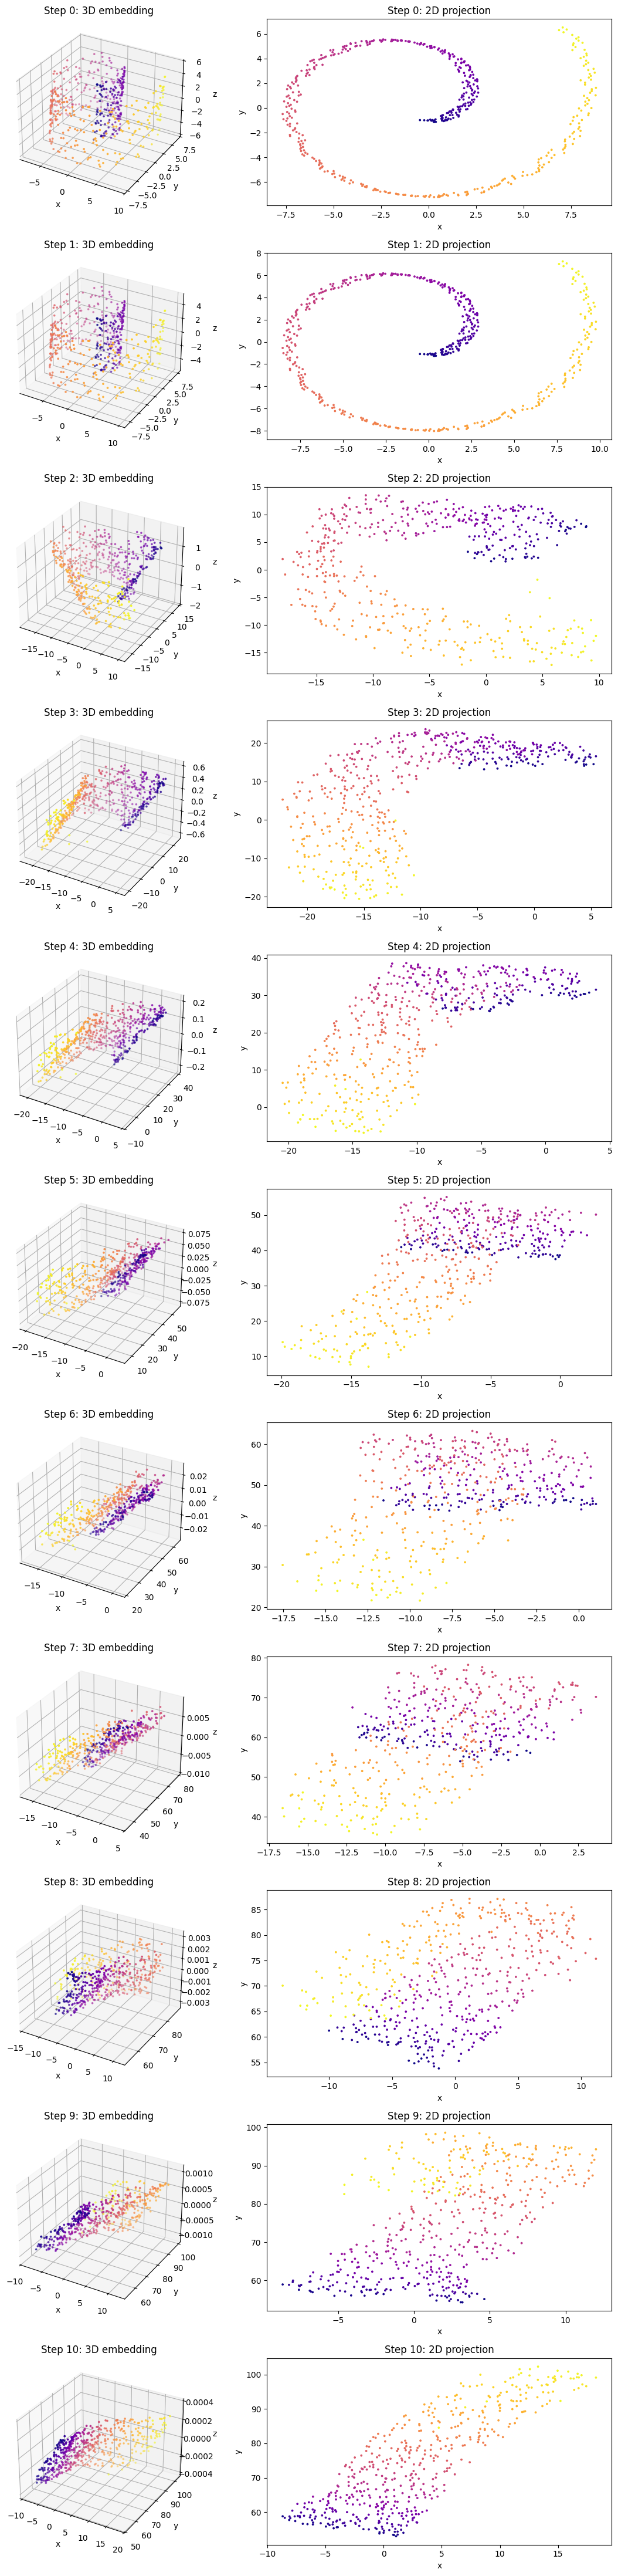

In [7]:
# Generate and centre the swiss roll dataset
data = create_swiss_roll(500)
coords = data[:, :3].astype(np.float32) # take only x, y, z columns
coords -= coords.mean(axis=0) # centre the data
phi = data[:, -1] # angle for coloring

# Initialise the refiner and prepare neighbourhood graph
refiner = EmbeddingRefiner(neighbors=32, embedding_dim=2, max_epochs=100)

refiner.dataset = coords

# Compute graph structures and set initial parameters
(refiner.neighbor_indices,
 refiner.target_distances,
 refiner.avg_target_distance,
 refiner.neighbor_collinear,
 refiner.target_angles) = refiner._prepare_graph()

refiner.step_scale = refiner.avg_target_distance
refiner.positions = refiner._compute_pca()
refiner.dims_preserved = np.arange(refiner.embedding_dim)
refiner.dims_shrunk = np.arange(refiner.embedding_dim, coords.shape[1])
refiner.current_scale = 1.0

# Record initial state
states = [refiner.positions.copy()]

# Perform a few optimisation steps and record intermediate embeddings
for iter in range(refiner.max_epochs):
    
    _ = refiner._epoch_step()

    if iter % 10 == 0:
        states.append(refiner.positions.copy())

# Plot the sequence of embeddings
num_states = len(states)
fig = plt.figure(figsize=(12, 4 * num_states))
for idx, state in enumerate(states):
    # 3D embedding plot
    ax3d = fig.add_subplot(num_states, 2, 2*idx + 1, projection='3d')
    ax3d.scatter(state[:, 0], state[:, 1], state[:, 2], c=phi, cmap='plasma', s=3)
    ax3d.set_title(f'Step {idx}: 3D embedding')
    ax3d.set_xlabel('x')
    ax3d.set_ylabel('y')
    ax3d.set_zlabel('z')
    # 2D projection plot
    ax2d = fig.add_subplot(num_states, 2, 2*idx + 2)
    ax2d.scatter(state[:, 0], state[:, 1], c=phi, cmap='plasma', s=3)
    ax2d.set_title(f'Step {idx}: 2D projection')
    ax2d.set_xlabel('x')
    ax2d.set_ylabel('y')

plt.tight_layout()
plt.show()


## Isomap and Kernel PCA

**Isomap** extends Multidimensional Scaling by replacing Euclidean distances with geodesic distances along the data manifold. To compute these distances we:

1. Build a $k$–nearest neighbour graph $G$ on the data points.
2. Assign edge weights equal to the Euclidean distances between connected vertices.
3. Compute the shortest-path distances $d_{i,j}$ in $G$ using the Floyd–Warshall algorithm or Dijkstra's algorithm.

After obtaining the geodesic distance matrix $D$, we perform **double centring** to form the Gram matrix


$
B = -\frac{1}{2}
\left(I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top\right)
D^{2}
\left(I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top\right),
$

whose eigenvectors corresponding to the largest eigenvalues provide the low-dimensional embedding.

**Kernel PCA** generalises PCA by implicitly mapping data to a high-dimensional feature space via a kernel function $k(\mathbf{x},\mathbf{y})$.
We form the kernel matrix $K$ with entries $K_{i,j} = k(\mathbf{x}_i,\mathbf{x}_j)$, centre it, and then perform an eigen decomposition.
The embeddings are obtained by scaling the eigenvectors by the square roots of their eigenvalues.

In [8]:
def _dijkstra_all_pairs(weight_matrix: np.ndarray) -> np.ndarray:
    """
    Compute all-pairs shortest paths using Dijkstra.

    return : Matrix of geodesic distances between all pairs of nodes.
    """
    n = weight_matrix.shape[0]                      # number of nodes
    dist = np.full((n, n), np.inf, dtype=float)     # initialise distance matrix to infinity

    for src in range(n):
        # Standard Dijkstra from source src
        d = dist[src]    # reference to row for source src
        d[src] = 0.0     # distance to self is zero

        visited = np.zeros(n, dtype=bool) # visited flags

        heap: list[Tuple[float, int]] = [(0.0, src)] # min-heap of (distance, node)

        while heap: # process nodes in order of distance

            cur_dist, u = heapq.heappop(heap) # get node with smallest distance
            
            if visited[u]: # if already visited skip
                continue
            
            visited[u] = True # mark as visited

            if cur_dist > d[u]: # if we found a longer path, skip
                continue

            neighbors = np.where(np.isfinite(weight_matrix[u]))[0] # get neighbors of u where weight is finite

            for v in neighbors: # loop over neighbors

                w = weight_matrix[u, v] # weight of edge u -> v

                new_dist = cur_dist + w # compute new distance

                if new_dist < d[v]: # if new distance is shorter

                    d[v] = new_dist # update distance

                    heapq.heappush(heap, (new_dist, v)) # push updated distance to heap

    return dist

In [9]:
def compute_geodesic_distances(points: np.ndarray, n_neigh: int) -> np.ndarray:
    """
    Builds a k-nearest-neighbor graph using Euclidean distances and then
    computes shortest-path distances (geodesics) along that graph.

    points : Input data points lying (approximately) on a low-dimensional manifold.
    n_neigh : Number of nearest neighbors to connect for each point when building the graph. Must satisfy 1 <= n_neigh < n_samples.

    geodesic_distances : Matrix of geodesic distances between all pairs of points. Entries may  be np.inf if the k-NN graph is disconnected.
    """

    points = np.asarray(points, dtype=float) # ensure points are float array

    # Validate inputs
    if points.ndim != 2: 
        raise ValueError("points must be a 2D array of shape (n_samples, n_features)")

    n_samples = points.shape[0] # number of samples

    # Validate n_neigh
    if not (1 <= n_neigh < n_samples): 
        raise ValueError("n_neigh must satisfy 1 <= n_neigh < n_samples")

    # Compute full pairwise Euclidean distances

    sq_norms = np.sum(points ** 2, axis=1, keepdims=True)       # squared norms of each point
    
    sq_dists = sq_norms + sq_norms.T - 2 * points @ points.T    # pairwise squared distances
    
    np.maximum(sq_dists, 0.0, out=sq_dists)  # numerical stability

    dists = np.sqrt(sq_dists) # pairwise Euclidean distances

    # Build k-NN graph: keep only edges to n_neigh nearest neighbors
    knn_graph = np.full_like(dists, np.inf, dtype=float)

    for i in range(n_samples):
        row = dists[i].copy() # copy row to avoid modifying original distances

        row[i] = np.inf  # ignore self
        
        neigh_idx = np.argpartition(row, n_neigh)[:n_neigh] # indices of n_neigh nearest neighbors

        knn_graph[i, neigh_idx] = dists[i, neigh_idx] # set distances for neighbors

    # Make graph undirected by taking the minimum distance in each direction
    knn_graph = np.minimum(knn_graph, knn_graph.T)

    # All-pairs shortest paths = geodesic distances
    geodesic_distances = _dijkstra_all_pairs(knn_graph)
    
    return geodesic_distances

In [10]:
def isomap_embedding(points: np.ndarray, target_dim: int, n_neigh: int = 5) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute an Isomap embedding of the data.

    points : Data of shape ``(n_samples, n_features)``.
    target_dim : Desired dimensionality of the embedding.
    n_neigh : Number of neighbours to use when building the geodesic graph.  Default is 5.

    tuple : A triple ``(embedding, eigenvalues, eigenvectors)`` where ``embedding`` has shape ``(n_samples, target_dim)``.
    """
    # Compute geodesic distances via Dijkstra on k-NN graph
    geodesic = compute_geodesic_distances(points, n_neigh)

    # Convert distances to squared form
    geodesic_squared = geodesic ** 2
    
    n = geodesic.shape[0] # number of samples
    
    # Double centring to obtain the Gram matrix
    identity = np.eye(n)
    centering = identity - np.ones((n, n)) / n
    gram = -0.5 * centering @ geodesic_squared @ centering

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(gram)
    
    # Sort by decreasing magnitude of eigenvalues
    order = np.argsort(-np.abs(eigenvalues))
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Select top ``target_dim`` components and construct embedding
    selected_vals = np.diag(np.abs(eigenvalues[:target_dim]))
    selected_vecs = eigenvectors[:, :target_dim]
    embedding = selected_vecs @ np.sqrt(selected_vals)
    
    return embedding, selected_vals, selected_vecs

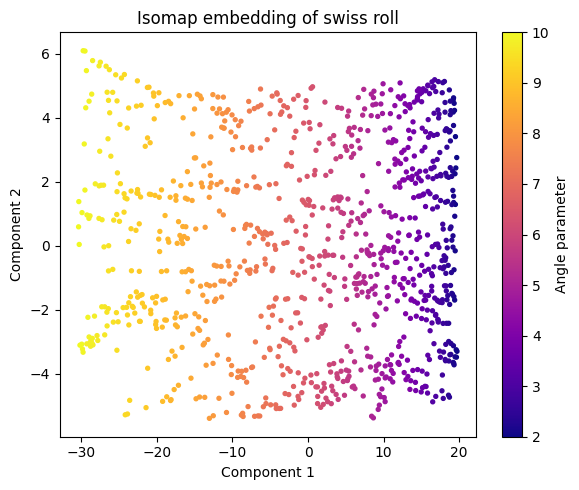

In [11]:
# Generate data
data = create_swiss_roll(1000)
X_3d = data[:, :3]       # 3D coordinates
color_param = data[:, 3] # angle for coloring

# Compute embedding
embedding, _, _ = isomap_embedding(X_3d, target_dim=2, n_neigh=10)

# Plot 2D embedding
plt.figure(figsize=(6, 5))
sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=color_param, s=8, cmap="plasma")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title(f"Isomap embedding of swiss roll")
cbar = plt.colorbar(sc)
cbar.set_label("Angle parameter")
plt.tight_layout()
plt.show()


## Kernel PCA

In [12]:
def kernel_pca(
    data: np.ndarray,
    kernel: Callable[..., float],
    **kernel_params: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Perform Kernel Principal Component Analysis on the input data.

    data : numpy.ndarray
        Input data of shape ``(n_samples, n_features)``.
    kernel : callable
        Kernel function of the form ``k(x, y, **params) -> float``.
    **kernel_params : dict, optional
        Additional parameters passed to ``kernel``.

    tuple : A triple ``(embedding, eigenvalues, eigenvectors)`` analogous to :func:`isomap_embedding`.  
        The embedding matrix contains as many
        dimensions as there are eigenvalues.
    """
    n_samples = data.shape[0] # number of samples

    # Construct the kernel matrix by evaluating the kernel on all pairs
    K = np.zeros((n_samples, n_samples), dtype=np.float64)
    
    for i in range(n_samples):
        for j in range(n_samples):
            K[i, j] = kernel(data[i], data[j], **kernel_params) # evaluate kernel
    
    # Centre the kernel matrix
    centering = np.eye(n_samples) - np.ones((n_samples, n_samples)) / n_samples
    K_centered = centering @ K @ centering

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(K_centered)
    order = np.argsort(-np.abs(eigenvalues))
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Form the embedding by scaling eigenvectors by the square roots of eigenvalues
    # Negative eigenvalues may arise due to numerical error; take absolute value
    embedding = eigenvectors @ np.diag(np.sqrt(np.abs(eigenvalues)))
    
    return embedding, eigenvalues, eigenvectors

In [13]:
# --- define a kernel (RBF / Gaussian) ---
def rbf_kernel(x: np.ndarray, y: np.ndarray, gamma: float = 0.02) -> float:
    diff = x - y
    return np.exp(-gamma * np.dot(diff, diff))

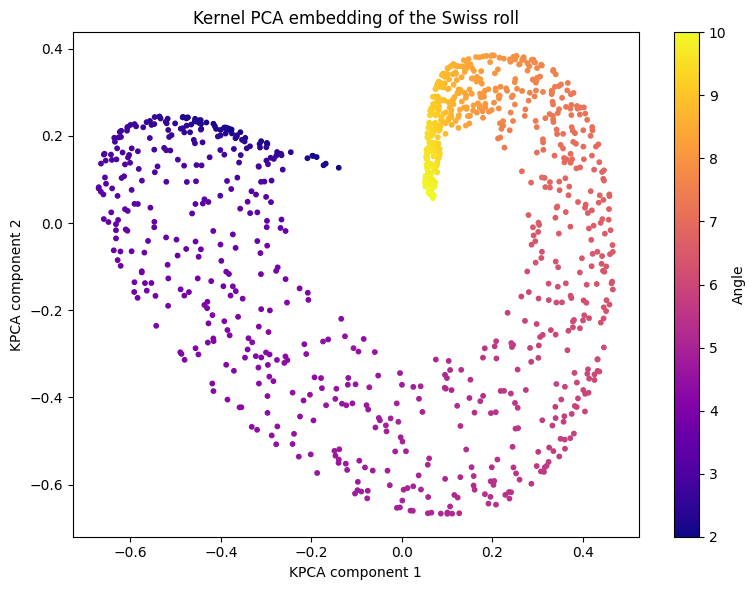

In [14]:
# --- generate data and run kernel PCA ---

num_points = 1000
data = create_swiss_roll(num_points)

X = data[:, :3]       # 3D coordinates
angle = data[:, 3]    # angular parameter for coloring

embedding, eigenvalues, eigenvectors = kernel_pca(
    X,
    kernel=rbf_kernel,
    gamma=0.05,       # tweak this to change how much it “unrolls”
)

# --- plot first two components of the embedding ---

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=angle,
    s=10,
    cmap='plasma'
)
plt.xlabel("KPCA component 1")
plt.ylabel("KPCA component 2")
plt.title("Kernel PCA embedding of the Swiss roll")
plt.colorbar(scatter, label="Angle")
plt.tight_layout()
plt.show()

## Image manifold experiment

In [15]:
from PIL import Image

In [16]:
# --- Parameters for the experiment ---
# Size of the background image (height and width)
bg_size = 64  # pixels
# Size of the face (foreground) image
face_size = 32  # pixels
# Number of points along each grid axis
n_grid = 20  # creates n_grid x n_grid samples

# Load and resize the face image
face_path = '/Users/leonardoangellotti/Desktop/universita/unsupervised/esame/lynch.png'
face_img = Image.open(face_path).convert('RGB')
face_img = face_img.resize((face_size, face_size))
face_array = np.array(face_img) / 255.0  # normalise to [0, 1]

# Create a single random noise background (RGB)
np.random.seed(0)  # for reproducibility
background = np.random.rand(bg_size, bg_size, 3)

# Compute evenly spaced offsets so that the face fits entirely within the background
offsets = np.linspace(0, bg_size - face_size, n_grid).astype(int)

# Prepare data containers
X = []  # flattened images
intrinsic_coords = []  # (i, j) grid positions
edges = []  # list of edges for plotting

# Build the dataset
for i, x in enumerate(offsets):
    for j, y in enumerate(offsets):
        # Place the face on the background at (x, y)
        canvas = background.copy()
        canvas[x:x + face_size, y:y + face_size] = face_array
        X.append(canvas.flatten())
        intrinsic_coords.append((i, j))
        # Record edges between neighbours (right and down) for plotting
        idx = i * n_grid + j
        if i + 1 < n_grid:
            edges.append((idx, (i + 1) * n_grid + j))
        if j + 1 < n_grid:
            edges.append((idx, i * n_grid + (j + 1)))

# Convert lists to arrays
X = np.array(X)
intrinsic_coords = np.array(intrinsic_coords)
print(f"Generated {len(X)} images with {X.shape[1]} features each.")


Generated 400 images with 12288 features each.


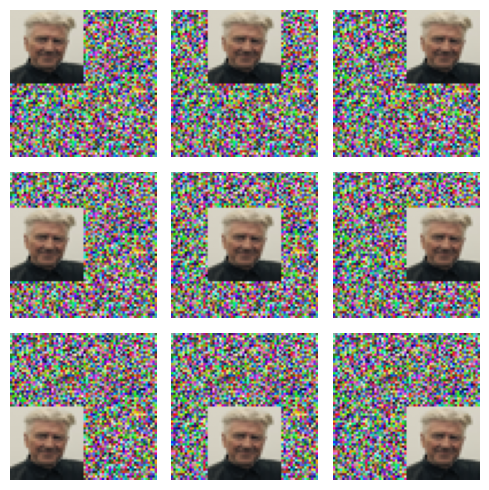

In [17]:
def plot_key_positions(X, bg_size, n_grid):
    # Define 9 key grid positions
    positions = [
        (0, 0),                    # top-left corner
        (0, n_grid//2),            # top-middle
        (0, n_grid-1),             # top-right corner
        
        (n_grid//2, 0),            # middle-left
        (n_grid//2, n_grid//2),    # center
        (n_grid//2, n_grid-1),     # middle-right
        
        (n_grid-1, 0),             # bottom-left corner
        (n_grid-1, n_grid//2),     # bottom-middle
        (n_grid-1, n_grid-1)       # bottom-right corner
    ]

    # Convert (i, j) → index in X
    indices = [i * n_grid + j for (i, j) in positions]

    fig, axes = plt.subplots(3, 3, figsize=(5, 5))

    for ax, idx in zip(axes.flatten(), indices):
        img = X[idx].reshape(bg_size, bg_size, 3)
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Call it
plot_key_positions(X, bg_size, n_grid)


In [18]:
n_neighbors = 8

In [19]:
embedding_pca, _, _ = kernel_pca(X, kernel=rbf_kernel, gamma=0.0002)

In [20]:
embedding_iso, _, _ = isomap_embedding(X, target_dim=2, n_neigh=n_neighbors)

In [ ]:
# Manifold Sculpting (using EmbeddingRefiner)
refiner = EmbeddingRefiner(neighbors=n_neighbors, embedding_dim=2, max_epochs=400, damping=0.97, early_stopping=80)
refiner.fit(X) # use the 3D latent codes as input
Y_manifold = refiner.best_positions[:, :2]  # take only the first two dimensions

In [22]:
# Collect embeddings in a dictionary for convenience
embeddings = {
    'PCA': embedding_pca,
    'Isomap': embedding_iso,
    'Manifold Sculpting': Y_manifold,
}

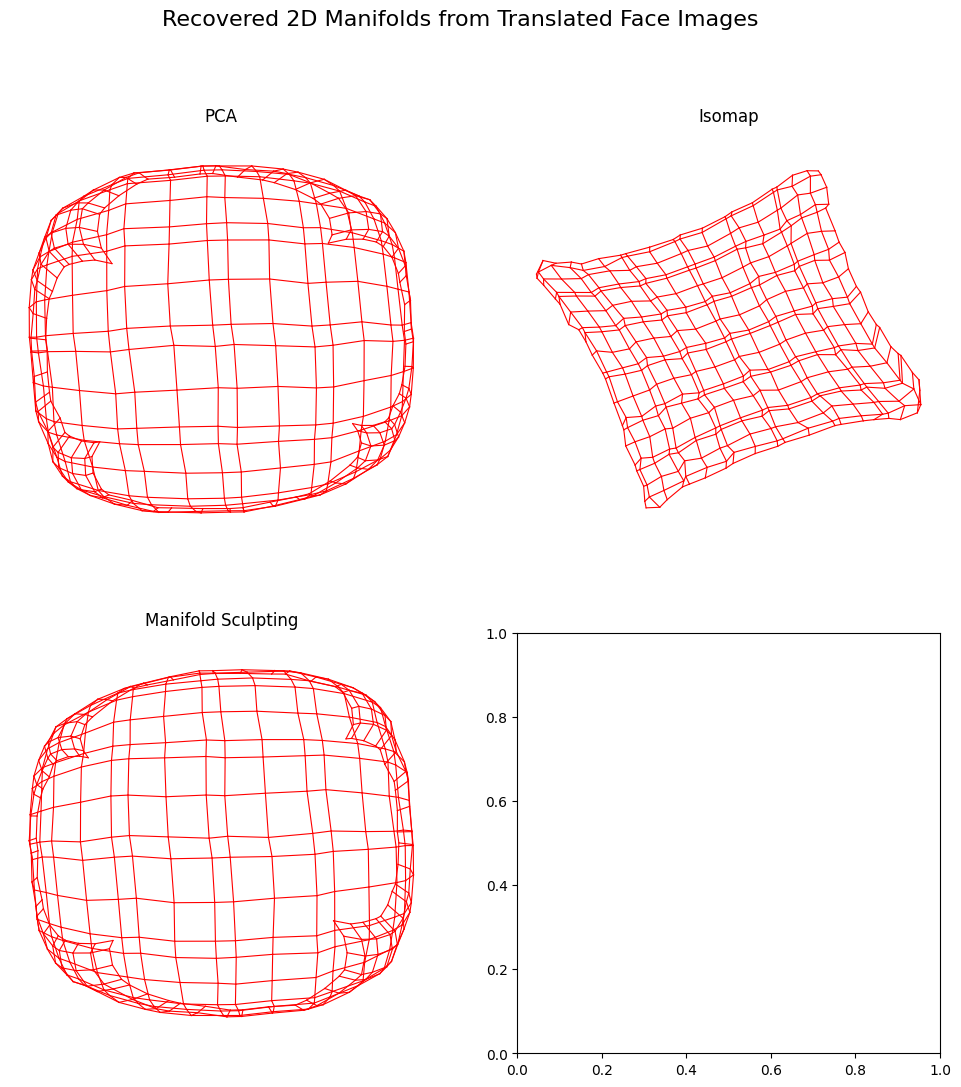

In [23]:
# --- Visualise the embeddings ---

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
methods = list(embeddings.keys())
for ax, method in zip(axes.flatten(), methods):
    coords = embeddings[method]
    # Normalize coordinates for better visual appearance
    coords = coords - coords.mean(axis=0)
    max_abs = np.abs(coords).max()
    if max_abs > 0:
        coords = coords / max_abs
    # Plot grid edges
    for (a, b) in edges:
        ax.plot([coords[a, 0], coords[b, 0]], [coords[a, 1], coords[b, 1]], color='red', linewidth=0.8)
    ax.set_title(method)
    ax.axis('equal')
    ax.axis('off')

plt.suptitle('Recovered 2D Manifolds from Translated Face Images', fontsize=16)
plt.show()


## reduce dim. using encoder

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

# Hyperparameters
latent_dim = 3
hidden_dim = 128  # size of hidden layer in encoder/decoder
random_state = 0

n_samples, n_features = X.shape

# Create training and validation split
# X_train, X_val = train_test_split(X, test_size=0.2, random_state=random_state)

# Simple autoencoder with tied-like architecture using two MLPs
encoder = MLPRegressor(
    hidden_layer_sizes=(hidden_dim,),
    activation="relu",
    solver="adam",
    random_state=random_state,
    max_iter=200,
)

# We'll train the encoder to predict a low-dimensional projection using PCA init
from sklearn.decomposition import PCA
pca = PCA(n_components=latent_dim, random_state=random_state)
Z_init = pca.fit_transform(X)

encoder.fit(X, Z_init)

# Get 3D latent codes for all points
Z = encoder.predict(X)

print("Latent representation shape:", Z.shape)


Latent representation shape: (400, 3)


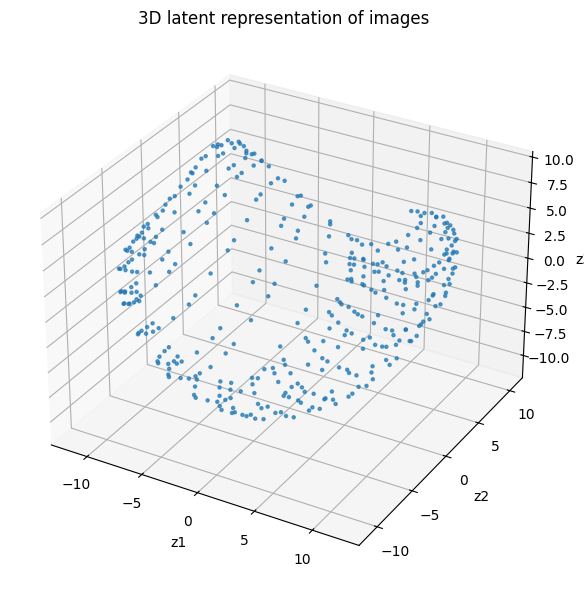

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Assuming Z is already computed as in your code: shape (n_samples, 3)
# Optional: if you also have intrinsic_coords, you can color by the grid index

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Basic 3D scatter of latent points
ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], s=5, alpha=0.7)

ax.set_xlabel('z1')
ax.set_ylabel('z2')
ax.set_zlabel('z3')
ax.set_title('3D latent representation of images')

plt.tight_layout()
plt.show()
